# 데이터 전처리 - 7,8,9를 순서 및 의미 고려하여 처리하기

### 기본 라이브러리 및 설정 불러오기

In [1]:
import numpy as np, pandas as pd, optuna, seaborn as sns, matplotlib.pyplot as plt, scipy.io as siodlt 
import os, sys, math, copy, glob, warnings, random
warnings.simplefilter(action='ignore', category=FutureWarning)

# system = platform.system()
# if system == 'Darwin':  
#     rc('font', family='AppleGothic') # 한국어 깨짐 방지용
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] =False

# 행,열 전체 확인하는 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# 난수 값 고정
SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

c:\DB\ml-project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 데이터프레임 불러오기

In [2]:
df = pd.read_csv(r'C:\DB\Health Care\Busan\chs24.csv')

#### 컬럼명 한글로 변경

In [3]:
kor_col_dict = {
    'age' : '만나이',
    'sex' : '성별',
    'PBHLTH_CODE' : '보건소번호',
    'SPOT_NO' : '표본지점번호',
    'HSHLD_CODE' : '가구번호',
    'mbhld_co' : '가구원번호',
    'wt_h' : '가구가중치',
    'wt_p': '개인가중치',
    'fma_19z3' : '세대유형',
    'fma_04z1' : '기초생활수급자',
    'fma_13z1': '가구 연소득',
    'fma_14z1' : '가구 월소득',
    'fma_27z1' : '치매 환자 가족 여부',
    'fma_26z1' : '치매환자 가구 거주 여부',
    'qoa_01z1' : '건강수준',
    'smf_01z1' : '흡연 경험',
    'sma_01z1' : '일반담배 흡연 경험',
    'sma_03z2' : '일반담배 현재 흡연 여부',
    'smb_01z1' : '일반담배 하루 평균 흡연량',
    'smb_02z1' : '일반담배 간헐적 흡연자의 흡연일수',
    'smb_03z1' : '일반담배 간헐적 흡연자의 하루 평균 흡연량',
    'smb_04z1' : '일반담배 과거흡연자의 흡연기간(년)',
    'smb_05z1' : '일반담배 과거흡연자의 흡연기간(월)',
    'smb_06z1' : '일반담배 과거흡연자의 하루 평균 흡연량',
    'smb_09z1' : '일반담배 과거흡연자의 금연기간',
    'sma_36z1' : '궐련형 전자담배 흡연 경험',
    'sma_37z1' : '궐련형 전자담배 현재 흡연 여부',
    'smb_11z1' : '궐련형 전자담배 하루 평균 흡연량',
    'smb_12z1' : '궐련형 전자담배 간헐적 흡연자의 흡연일수',
    'smb_13z1' : '궐련형 전자담배 간헐적 흡연자의 하루 평균 흡연량',
    'sma_08z1' : '액상형 전자담배 흡연 경험',
    'sma_11z2' : '액상형 전자담배 흡연자의 흡연일수',
    'sma_12z2' : '타 종류 담배 사용 경험',
    'smc_08z2' : '가정 간접흡연 여부',
    'smc_09z2' : '가정 간접흡연 경험 여부',
    'smc_10z2' : '직장 간접흡연 경험 여부',
    'dra_01z1' : '음주 경험',
    'drb_01z3' : '연간 음주 빈도',
    'drb_03z1' : '1회 음주량',
    'drb_16z1' : '10잔 이상 섭취시 음주량',
    'drb_04z1' : '월간 폭음 경험(남)',
    'drb_05z1' : '월간 폭음 경험(여)',
    'dre_03z1' : '음주폐해 예방 및 절주 홍보 경험',
    'dre_04z1' : '음주폐해 예방 및 절주 교육 경험',
    'pha_04z1' : '고강도 신체활동(일)',
    'pha_05z1' : '고강도 신체활동(시)',
    'pha_06z1' : '고강도 신체활동(분)',
    'pha_07z1' : '중강도 신체활동(일)',
    'pha_08z1' : '중강도 신체활동(시)',
    'pha_09z1' : '중강도 신체활동(분)',
    'phb_01z1' : '걷기 실천(일)',
    'phb_02z1' : '걷기 실천(시)',
    'phb_03z1' : '걷기 실천(분)',
    'nua_01z2' : '아침식수 일수',
    'oba_02z1' : '키',
    'oba_03z1' : '몸무게',
    'oba_bmi' : 'BMI',
    'mtc_17z1' : '주중 평균 수면시간',
    'mtc_18z1' : '주말 평균 수면시간',
    'mta_01z1' : '스트레스 수준',
    'mta_02z1' : '스트레스로 인한 정신상담 여부',
    'mtb_01z1' : '우울감 경험',
    'mtb_02z1' : '우울증상으로 인한 정신상담 여부',
    'mtb_07a1' : '직무 흥미 저하',
    'mtb_07b1' : '우울감',
    'mtb_07c1' : '수면장애',
    'mtb_07d1' : '무기력',
    'mtb_07e1' : '식이장애',
    'mtb_07f1' : '자기비하',
    'mtb_07g1' : '집중력저하',
    'mtb_07h1' : '활동둔화',
    'mtb_07i1' : '자살충동',
    'mtd_01z1' : '자살충동 여부',
    'mtd_02z1' : '자살충동으로 인한 정신상담 여부',
    'edit_mtc_03z1' : '취침(시)',
    'mtc_04z1' : '취침(분)',
    'mtc_05z1' : '수면소요(시)',
    'mtc_06z1' : '수면소요(분)',
    'mtc_08z1' : '기상(시)',
    'mtc_09z1' : '기상(분)',
    'mtc_10z1' : '실수면(시)',
    'mtc_11z1' : '실수면(분)',
    'mtc_12a1' : '불면증',
    'mtc_12b1' : '수면유지장애',
    'mtc_12c1' : '야뇨증',
    'mtc_12d1' : '수면호흡장애',
    'mtc_12e1' : '수면 중 기침 및 코골이',
    'mtc_12f1' : '수면 중 한기',
    'mtc_12g1' : '수면 중 열감',
    'mtc_12i1' : '수면 중 통증',
    'mtc_13z1' : '수면 질',
    'mtc_14z1' : '수면 약 복용',
    'mtc_15z1' : '생활 중 졸음 정도',
    'mtc_16z1' : '업무 몰입 저하(졸음)',
    'mtj_05z2' : '인지장애 경험 여부',
    'mtj_06z2' : '일상생활(인지)',
    'mtj_09z2' : '사회생활(인지)',
    'mtj_10z1' : '인지장애 상담 여부',
    'mtj_11z1' : '치매선별검사 여부',
    'hya_04z1' : '고혈압 진단',
    'hya_15z1' : '혈압조절 인지',
    'hya_14c2' : '혈압관리 비약물',
    'hya_14a2' : '혈압관리 약물',
    'hya_14b2' : '혈압약 복용일수',
    'hya_30z1' : '혈압조절 여부',
    'hya_10z1' : '고혈압 교육',
    'dia_04z1' : '당뇨병 진단',
    'dia_18z1' : '혈당조절 인지',
    'dia_13c2' : '당뇨치료 비약물',
    'dia_13b2' : '당뇨치료 당뇨약',
    'dia_13a2' : '당뇨치료 인슐린',
    'dia_09z1' : '당뇨병 교육',
    'dia_22z2' : '당화혈색소 검사',
    'sra_01z3' : '의료미충족',
    'sra_02z2' : '의료미충족 여부',
    'qoc_07z1' : '행복지수',
    'qoc_01z1' : '운동 능력',
    'qoc_02z1' : '자기 관리',
    'qoc_03z1' : '일상 활동',
    'qoc_04z1' : '통증 불편',
    'qoc_05z1' : '불안 우울',
    'hma_01z3' : '보건기관 이용',
    'sob_01z1' : '교육 수준',
    'sob_02z1' : '졸업 여부',
    'soa_01z1' : '경제 활동',
    'soa_06z2' : '업종',
    'soa_07z1' : '종사 지위',
    'sod_02z3' : '혼인'
 }

df.rename(columns= kor_col_dict, inplace=True)

In [4]:
df.columns.tolist()

['EXAMIN_YEAR',
 'exmprs_no',
 '만나이',
 '성별',
 'CTPRVN_CODE',
 '보건소번호',
 '표본지점번호',
 '가구번호',
 'MBHLD_CODE',
 'DONG_TY_CODE',
 'HOUSE_TY_CODE',
 'signgu_code',
 'kstrata',
 '가구가중치',
 '개인가중치',
 '가구원번호',
 'reside_adult_co',
 '세대유형',
 '기초생활수급자',
 'fma_12z1',
 '가구 연소득',
 '가구 월소득',
 'fma_24z2',
 'nue_01z1',
 '치매 환자 가족 여부',
 '치매환자 가구 거주 여부',
 '건강수준',
 '흡연 경험',
 '일반담배 흡연 경험',
 '일반담배 현재 흡연 여부',
 '일반담배 하루 평균 흡연량',
 '일반담배 간헐적 흡연자의 흡연일수',
 '일반담배 간헐적 흡연자의 하루 평균 흡연량',
 '일반담배 과거흡연자의 흡연기간(년)',
 '일반담배 과거흡연자의 흡연기간(월)',
 '일반담배 과거흡연자의 하루 평균 흡연량',
 '일반담배 과거흡연자의 금연기간',
 '궐련형 전자담배 흡연 경험',
 '궐련형 전자담배 현재 흡연 여부',
 '궐련형 전자담배 하루 평균 흡연량',
 '궐련형 전자담배 간헐적 흡연자의 흡연일수',
 '궐련형 전자담배 간헐적 흡연자의 하루 평균 흡연량',
 '액상형 전자담배 흡연 경험',
 '액상형 전자담배 흡연자의 흡연일수',
 '타 종류 담배 사용 경험',
 'smd_02z3',
 'smd_01z3',
 '가정 간접흡연 여부',
 '가정 간접흡연 경험 여부',
 '직장 간접흡연 경험 여부',
 '음주 경험',
 '연간 음주 빈도',
 '1회 음주량',
 '10잔 이상 섭취시 음주량',
 '월간 폭음 경험(남)',
 '월간 폭음 경험(여)',
 'drg_01z3',
 '음주폐해 예방 및 절주 홍보 경험',
 '음주폐해 예방 및 절주 교육 경험',
 'sfa_02z3',
 'sfb_05z2',
 'sfa_12z2',
 'sfb

In [5]:
# 영어 컬럼 제거
import re

kor_type = re.compile(r'^[가-힣\s]+$')
kor_col = [col for col in df.columns if kor_type.fullmatch(col) or col == 'BMI']

df1 = df[kor_col]
print(df1.columns.tolist())

['만나이', '성별', '보건소번호', '표본지점번호', '가구번호', '가구가중치', '개인가중치', '가구원번호', '세대유형', '기초생활수급자', '가구 연소득', '가구 월소득', '치매 환자 가족 여부', '치매환자 가구 거주 여부', '건강수준', '흡연 경험', '일반담배 흡연 경험', '일반담배 현재 흡연 여부', '일반담배 하루 평균 흡연량', '일반담배 간헐적 흡연자의 흡연일수', '일반담배 간헐적 흡연자의 하루 평균 흡연량', '일반담배 과거흡연자의 하루 평균 흡연량', '일반담배 과거흡연자의 금연기간', '궐련형 전자담배 흡연 경험', '궐련형 전자담배 현재 흡연 여부', '궐련형 전자담배 하루 평균 흡연량', '궐련형 전자담배 간헐적 흡연자의 흡연일수', '궐련형 전자담배 간헐적 흡연자의 하루 평균 흡연량', '액상형 전자담배 흡연 경험', '액상형 전자담배 흡연자의 흡연일수', '타 종류 담배 사용 경험', '가정 간접흡연 여부', '가정 간접흡연 경험 여부', '직장 간접흡연 경험 여부', '음주 경험', '연간 음주 빈도', '음주폐해 예방 및 절주 홍보 경험', '음주폐해 예방 및 절주 교육 경험', '아침식수 일수', '키', '몸무게', 'BMI', '주중 평균 수면시간', '주말 평균 수면시간', '스트레스 수준', '스트레스로 인한 정신상담 여부', '우울감 경험', '우울증상으로 인한 정신상담 여부', '직무 흥미 저하', '우울감', '수면장애', '무기력', '식이장애', '자기비하', '집중력저하', '활동둔화', '자살충동', '자살충동 여부', '자살충동으로 인한 정신상담 여부', '불면증', '수면유지장애', '야뇨증', '수면호흡장애', '수면 중 기침 및 코골이', '수면 중 한기', '수면 중 열감', '수면 중 통증', '수면 질', '수면 약 복용', '생활 중 졸음 정도', '인지장애 경험 여부', '인지장애 상담 여부', '치매선별검사 여부', '고혈압 진단', '혈압조절 인지', '혈압관리 비

C:\Users\PANG\AppData\Local\Temp\ipykernel_27816\522988434.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['연령대'] = pd.cut(df1['만나이'], bins=bins, labels=labels, right=True, include_lowest=True)


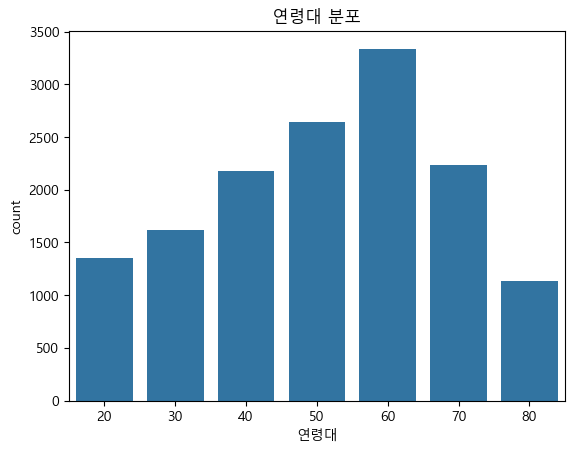

In [6]:
# 만나이 19-29, 30-39, ..., 80 이상 연령대 컬럼 만들고 시각화
bins = [18, 29, 39, 49, 59, 69, 79, float('inf')]
labels = [20, 30, 40, 50, 60, 70, 80]

df1['연령대'] = pd.cut(df1['만나이'], bins=bins, labels=labels, right=True, include_lowest=True)

# 연령대별 분포 확인
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='연령대', data=df1)
plt.title("연령대 분포")
plt.show()

In [7]:
# 만 40세 이상으로 필터링 (인지장애 경험 여부 기준)

df_old = df1.copy()
df_old = df_old[df_old['만나이'] >= 40].copy()
df_old['연령대'] = df_old['연령대'].astype(int)
df_old.columns.tolist()

['만나이',
 '성별',
 '보건소번호',
 '표본지점번호',
 '가구번호',
 '가구가중치',
 '개인가중치',
 '가구원번호',
 '세대유형',
 '기초생활수급자',
 '가구 연소득',
 '가구 월소득',
 '치매 환자 가족 여부',
 '치매환자 가구 거주 여부',
 '건강수준',
 '흡연 경험',
 '일반담배 흡연 경험',
 '일반담배 현재 흡연 여부',
 '일반담배 하루 평균 흡연량',
 '일반담배 간헐적 흡연자의 흡연일수',
 '일반담배 간헐적 흡연자의 하루 평균 흡연량',
 '일반담배 과거흡연자의 하루 평균 흡연량',
 '일반담배 과거흡연자의 금연기간',
 '궐련형 전자담배 흡연 경험',
 '궐련형 전자담배 현재 흡연 여부',
 '궐련형 전자담배 하루 평균 흡연량',
 '궐련형 전자담배 간헐적 흡연자의 흡연일수',
 '궐련형 전자담배 간헐적 흡연자의 하루 평균 흡연량',
 '액상형 전자담배 흡연 경험',
 '액상형 전자담배 흡연자의 흡연일수',
 '타 종류 담배 사용 경험',
 '가정 간접흡연 여부',
 '가정 간접흡연 경험 여부',
 '직장 간접흡연 경험 여부',
 '음주 경험',
 '연간 음주 빈도',
 '음주폐해 예방 및 절주 홍보 경험',
 '음주폐해 예방 및 절주 교육 경험',
 '아침식수 일수',
 '키',
 '몸무게',
 'BMI',
 '주중 평균 수면시간',
 '주말 평균 수면시간',
 '스트레스 수준',
 '스트레스로 인한 정신상담 여부',
 '우울감 경험',
 '우울증상으로 인한 정신상담 여부',
 '직무 흥미 저하',
 '우울감',
 '수면장애',
 '무기력',
 '식이장애',
 '자기비하',
 '집중력저하',
 '활동둔화',
 '자살충동',
 '자살충동 여부',
 '자살충동으로 인한 정신상담 여부',
 '불면증',
 '수면유지장애',
 '야뇨증',
 '수면호흡장애',
 '수면 중 기침 및 코골이',
 '수면 중 한기',
 '수면 중 열감',
 '수면 중 통증',
 '수면 질',
 '수면 약 복용',
 '생활 중 졸음 정도',


### 1차 불필요한 컬럼 제거 - 도메인 지식 및 현실성 고려하여 제거

In [8]:
# 인지장애 경험 여부와 직접적인 관련이 있는 인지장애 상담 여부 컬럼 제거
# 인지장애 경험 여부와 관련이 없는 보건소번호, 표본지점번호, 가구번호, 가구가중치, 개인가중치, 가구원번호, 수집하기 까다로운 기초생활수급자 및 소득 컬럼, 인지장애 및 치매와 큰 관련이 없는 교육 경험 컬럼 제거
df_old.drop(columns = ['인지장애 상담 여부', 
                       '보건소번호', 
                       '표본지점번호', 
                       '가구번호', 
                       '가구가중치', 
                       '개인가중치', 
                       '가구원번호', 
                       '기초생활수급자', 
                       '가구 연소득', 
                       '가구 월소득',
                       '의료미충족 여부',
                       '교육 수준',
                       '졸업 여부',
                       '음주폐해 예방 및 절주 홍보 경험',
                       '음주폐해 예방 및 절주 교육 경험',
                       '고혈압 교육',
                       '당뇨병 교육'                   
                        ], inplace=True)

In [9]:
df_old.describe()

,만나이,성별,세대유형,치매 환자 가족 여부,치매환자 가구 거주 여부,건강수준,흡연 경험,일반담배 흡연 경험,일반담배 현재 흡연 여부,일반담배 하루 평균 흡연량,일반담배 간헐적 흡연자의 흡연일수,일반담배 간헐적 흡연자의 하루 평균 흡연량,일반담배 과거흡연자의 하루 평균 흡연량,일반담배 과거흡연자의 금연기간,궐련형 전자담배 흡연 경험,궐련형 전자담배 현재 흡연 여부,궐련형 전자담배 하루 평균 흡연량,궐련형 전자담배 간헐적 흡연자의 흡연일수,궐련형 전자담배 간헐적 흡연자의 하루 평균 흡연량,액상형 전자담배 흡연 경험,액상형 전자담배 흡연자의 흡연일수,타 종류 담배 사용 경험,가정 간접흡연 여부,가정 간접흡연 경험 여부,직장 간접흡연 경험 여부,음주 경험,연간 음주 빈도,아침식수 일수,키,몸무게,BMI,주중 평균 수면시간,주말 평균 수면시간,스트레스 수준,스트레스로 인한 정신상담 여부,우울감 경험,우울증상으로 인한 정신상담 여부,직무 흥미 저하,우울감,수면장애,무기력,식이장애,자기비하,집중력저하,활동둔화,자살충동,자살충동 여부,자살충동으로 인한 정신상담 여부,불면증,수면유지장애,야뇨증,수면호흡장애,수면 중 기침 및 코골이,수면 중 한기,수면 중 열감,수면 중 통증,수면 질,수면 약 복용,생활 중 졸음 정도,인지장애 경험 여부,치매선별검사 여부,고혈압 진단,혈압조절 인지,혈압관리 비약물,혈압관리 약물,혈압약 복용일수,혈압조절 여부,당뇨병 진단,혈당조절 인지,당뇨치료 비약물,당뇨치료 당뇨약,당뇨치료 인슐린,당화혈색소 검사,의료미충족,행복지수,운동 능력,자기 관리,일상 활동,통증 불편,불안 우울,보건기관 이용,경제 활동,업종,종사 지위,혼인,연령대
count,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.00000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.00000,11543.000000,11543.000000,11543.000000,11543.000000,11543.00000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000,11543.000000
mean,62.197696,1.568050,3.073291,1.886944,7.284675,2.940310,1.606428,5.627220,5.751711,769.796240,86.99255,876.296457,675.114875,7.174045,5.589448,7.707788,869.496578,87.667158,884.172659,5.604782,85.435935,6.022178,1.972018,7.812007,2.402322,1.160530,3.780820,1.611106,533.133137,306.488322,473.979191,6.496405,6.846920,3.097115,6.887984,1.923244,7.515897,1.374946,1.310924,1.705449,1.717664,1.287620,1.107598,1.111236,1.049467,1.084467,1.919172,7.493286,1.908516,2.291952,2.707009,1.088192,1.277398,1.112969,1.200381,1.330330,2.255826,1.220307,1.576973,1.746426,2.99922,1.643853,5.521268,5.777701,5.519796,68.35528,5.610760,1.832712,6.850645,6.944209,6.835225,6.987005,7.168500,1.993936,6.909642,1.186866,1.070865,1.128823,1.366802,1.161916,1.825089,1.452655,42.807676,4.588149,1.828034,57.825522
std,12.463806,0.495369,2.020815,0.349699,1.980728,0.879791,0.488563,2.947571,2.856809,298.821859,8.73750,100.985065,374.577561,1.651581,2.999529,1.302975,125.924024,5.081447,58.029997,2.978509,13.951374,2.457970,0.164929,1.110591,0.583937,0.367113,2.375208,1.112197,6054.300962,4864.791152,6695.359460,1.817186,1.928287,0.749639,2.372008,0.275178,1.676662,0.731926,0.663626,1.017969,0.867643,0.652966,0.444684,0.440063,0.325750,0.391674,0.281957,1.702212,1.210743,1.229304,1.162320,0.421874,0.733377,0.457772,0.600317,0.802734,0.725405,0.737206,0.955035,0.462114,2.44040,0.478880,3.339359,2.998983,3.336773,27.18226,3.306502,0.373249,2.575636,2.363260,2.599978,2.262110,1.952638,0.315594,3.172518,0.409124,0.283557,0.362828,0.542506,0.408960,0.379908,0.497775,41.168857,3.124379,1.314899,12.350021
min,40.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,130.000000,30.000000,13.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000

# 데이터를 범주형, 연속형으로 분류하여 전처리

## 7, 9 값들 결측치 처리 후 제거

In [10]:
map_dict = {
    '건강수준': [7, 9],
    '흡연 경험': [7, 9],
    '일반담배 현재 흡연 여부': [7, 9],
    '일반담배 하루 평균 흡연량': [777, 999],
    '일반담배 간헐적 흡연자의 흡연일수': [77, 99],
    '일반담배 간헐적 흡연자의 흡연량': [77, 99],
    '일반담배 과거흡연자의 흡연기간(년)': [77, 99],
    '일반담배 과거흡연자의 흡연기간(월)': [77, 99],
    '일반담배 과거흡연자의 하루 평균 흡연량': [777, 999],
    '일반담배 과거흡연자의 금연기간': [7, 9],
    '궐련형 전자담배 흡연 경험': [7, 9],
    '궐련형 전자담배 현재 흡연 여부': [7, 9],
    '궐련형 전자담배 하루 평균 흡연량': [777, 999],
    '궐련형 전자담배 간헐적 흡연자의 흡연일수': [77, 99],
    '궐련형 전자담배 간헐적 흡연자의 흡연량': [777, 999],
    '액상형 전자담배 흡연 경험': [7, 9],
    '액상형 전자담배 흡연자의 흡연일수': [77, 99],
    '타 종류 담배 사용 경험': [7, 9],
    '가정 간접흡연 여부': [9],
    '가정 간접흡연 경험 여부': [9],
    '직장 간접흡연 경험 여부': [7, 9],
    '음주 경험': [7],
    '연간 음주 빈도': [7, 9],
    '1회 음주량': [7, 9],
    '10잔 이상 섭취시 음주량': [77, 99],
    '월간 폭음 경험(남)': [7, 9],
    '월간 폭음 경험(여)': [7, 9],
    '음주폐해 예방 및 절주 홍보 경험': [7, 9],
    '음주폐해 예방 및 절주 교육 경험': [7, 9],
    '고강도 신체활동(일)': [77, 99],
    '고강도 신체활동(시)': [77, 99],
    '고강도 신체활동(분)': [77, 99],
    '중강도 신체활동(일)': [77, 99],
    '중강도 신체활동(시)': [77, 99],
    '중강도 신체활동(분)': [77, 99],
    '걷기 실천(일)': [77, 99],
    '걷기 실천(시)': [77, 99],
    '걷기 실천(분)': [77, 99],
    '주중 평균 수면시간': [77, 99],
    '주말 평균 수면시간': [77, 99],
    '스트레스 수준': [7, 9],
    '스트레스로 인한 정신상담 여부': [7, 9],
    '우울감 경험': [7, 9],
    '우울증상으로 인한 정신상담 여부': [7, 9],
    '직무 흥미 저하': [7, 9],
    '우울감': [7, 9],
    '수면장애': [7, 9],
    '무기력': [7, 9],
    '식이장애': [7, 9],
    '자기비하': [7, 9],
    '집중력저하': [7, 9],
    '활동둔화': [7, 9],
    '자살충동': [7, 9],
    '자살충동 여부': [7, 9],
    '자살충동으로 인한 정신상담': [7, 9],
    '취침(시)': [77, 99],
    '취침(분)': [77, 99],
    '수면소요(시)': [77, 99],
    '수면소요(분)': [77, 99],
    '기상(시)': [77, 99],
    '기상(분)': [77, 99],
    '실수면(시)': [77, 99],
    '실수면(분)': [77, 99],
    '불면증': [7, 9],
    '수면유지장애': [7, 9],
    '야뇨증': [7, 9],
    '수면호흡장애': [7, 9],
    '수면 중 기침 및 코골이': [7, 9],
    '수면 중 한기': [7, 9],
    '수면 중 열감': [7, 9],
    '수면 중 통증': [7, 9],
    '수면 질': [7, 9],
    '수면 약 복용': [7, 9],
    '생활 중 졸음 정도': [7, 9],
    '업무 몰입 저하(졸음)': [7, 9],
    '인지장애 경험 여부': [7, 9],
    '일상생활(인지)': [7, 9],
    '사회생활(인지)': [7, 9],
    '인지장애 상담 여부': [7, 9],
    '치매선별검사 여부': [9],
    '치매 환자 가족 여부' : [7, 9],
    '고혈압 진단': [9],
    '혈압조절 인지': [9],
    '혈압관리 비약물': [9],
    '혈압관리 약물': [9],
    '혈압약 복용일수': [77, 99],
    '혈압조절 여부': [9],
    '고혈압 교육': [9],
    '당뇨병 진단': [9],
    '혈당조절 인지': [9],
    '당뇨치료 비약물': [9],
    '당뇨치료 당뇨약': [9],
    '당뇨치료 인슐린': [9],
    '당뇨병 교육': [9],
    '당화혈색소 검사': [7, 9],
    '의료미충족': [9],
    '의료미충족 여부': [99],
    '행복지수': [77, 99],
    '운동 능력': [9],
    '일상활동': [9],
    '불안 우울': [9],
    '보건기관 이용': [9]
}
# 컬럼의 응답 거부, 모름 값들 결측치로 변경 
for col, invalid_vals in map_dict.items():
    if col in df_old.columns:
        df_old[col] = df_old[col].replace(invalid_vals, np.nan)

df_old.dropna(inplace=True)

In [11]:
# 1. 범주형 변수 - 명목형, 이진형 변수 (성별, 예/아니오 응답)
# 8은 제거, 7, 9 최빈값으로 대체
binary_col = []

for col in df_old.columns:
    unique_vals = set(df_old[col].dropna().unique())
    
    if {1, 2}.issubset(unique_vals) and unique_vals.isdisjoint({3, 4, 5, 6}):
        binary_col.append(col)

In [12]:
# 2. 수치형 변수
# 그대로 사용
continuous_col = ['만나이', '키', '몸무게', 'BMI']

# 3. 범주형 변수 - 명목형 변수 (제거필요)
nominal_col = ['세대유형', '업종', '종사 지위', '혼인']

# 4. 범주형 변수 - 순서형 (전체 변수에서 모든 변수 제외한 나머지)
# 8을 1로, 나머지는 순서대로 맵핑
ordinal_col = [
    col for col in df_old.columns
    if col not in binary_col
    and col not in continuous_col
    and col not in nominal_col
]

In [13]:
ordinal_col

['건강수준',
 '일반담배 흡연 경험',
 '일반담배 현재 흡연 여부',
 '일반담배 하루 평균 흡연량',
 '일반담배 간헐적 흡연자의 흡연일수',
 '일반담배 간헐적 흡연자의 하루 평균 흡연량',
 '일반담배 과거흡연자의 하루 평균 흡연량',
 '일반담배 과거흡연자의 금연기간',
 '궐련형 전자담배 현재 흡연 여부',
 '궐련형 전자담배 하루 평균 흡연량',
 '궐련형 전자담배 간헐적 흡연자의 흡연일수',
 '궐련형 전자담배 간헐적 흡연자의 하루 평균 흡연량',
 '액상형 전자담배 흡연자의 흡연일수',
 '타 종류 담배 사용 경험',
 '직장 간접흡연 경험 여부',
 '연간 음주 빈도',
 '아침식수 일수',
 '주중 평균 수면시간',
 '주말 평균 수면시간',
 '스트레스 수준',
 '직무 흥미 저하',
 '우울감',
 '수면장애',
 '무기력',
 '식이장애',
 '자기비하',
 '집중력저하',
 '활동둔화',
 '자살충동',
 '불면증',
 '수면유지장애',
 '야뇨증',
 '수면호흡장애',
 '수면 중 기침 및 코골이',
 '수면 중 한기',
 '수면 중 열감',
 '수면 중 통증',
 '수면 질',
 '수면 약 복용',
 '생활 중 졸음 정도',
 '혈압약 복용일수',
 '당화혈색소 검사',
 '의료미충족',
 '행복지수',
 '운동 능력',
 '자기 관리',
 '일상 활동',
 '통증 불편',
 '불안 우울',
 '연령대']

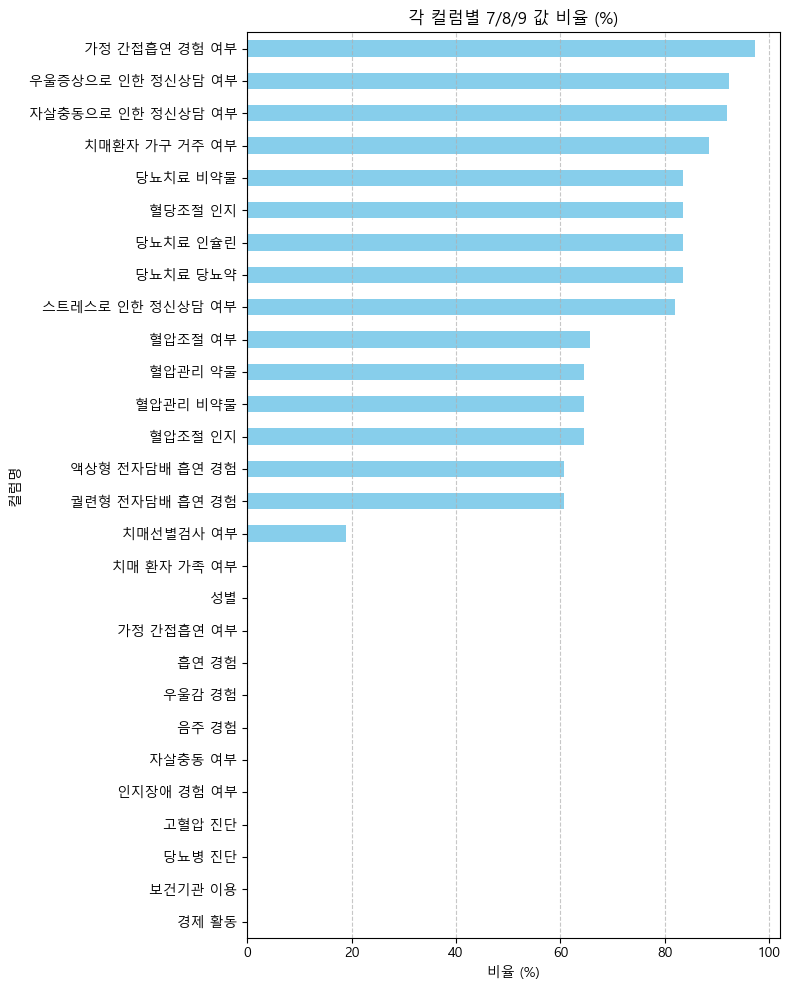

In [14]:
invalid_values = [7, 77, 777, 7777, 77777, 8, 88, 888, 8888, 88888, 9, 99, 999, 9999, 99999]

# 각 컬럼별로 7, 8, 9의 비율 계산
value_ratio = {}
for col in df_old.columns:
    if col in binary_col:
        total = df_old[col].notna().sum()
        if total == 0:
            ratio = 0
        else:
            ratio = df_old[col].isin(invalid_values).sum() / total * 100
        value_ratio[col] = ratio

ratios_series = pd.Series(value_ratio).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
ratios_series.plot(kind='barh', color='skyblue')
plt.title('각 컬럼별 7/8/9 값 비율 (%)')
plt.xlabel('비율 (%)')
plt.ylabel('컬럼명')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [15]:
ratios_series

가정 간접흡연 경험 여부        97.182976
우울증상으로 인한 정신상담 여부    92.316414
자살충동으로 인한 정신상담 여부    91.897785
치매환자 가구 거주 여부        88.452817
당뇨치료 비약물             83.385662
혈당조절 인지              83.385662
당뇨치료 인슐린             83.385662
당뇨치료 당뇨약             83.385662
스트레스로 인한 정신상담 여부     81.990232
혈압조절 여부              65.716030
혈압관리 약물              64.468864
혈압관리 비약물             64.468864
혈압조절 인지              64.468864
액상형 전자담배 흡연 경험       60.692482
궐련형 전자담배 흡연 경험       60.692482
치매선별검사 여부            18.969126
치매 환자 가족 여부           0.000000
성별                    0.000000
가정 간접흡연 여부            0.000000
흡연 경험                 0.000000
우울감 경험                0.000000
음주 경험                 0.000000
자살충동 여부               0.000000
인지장애 경험 여부            0.000000
고혈압 진단                0.000000
당뇨병 진단                0.000000
보건기관 이용               0.000000
경제 활동                 0.000000
dtype: float64

### 2차 컬럼 제거 - 범주형+이진형 변수의 7, 8, 9의 비율이 너무 큰 컬럼 제거, 명목형 변수 제거

In [16]:
# 범주형 변수 중 이진형에 해당하는 변수인데, 7, 8, 9가 특별한 사유가 없이 많은 경우 제거
del_binary_col = [
    '가정 간접흡연 경험 여부',
    '직장 간접흡연 경험 여부',
    '우울증상으로 인한 정신상담 여부',
    '자살충동으로 인한 정신상담 여부',
    '치매환자 가구 거주 여부',
    '혈당조절 인지',
    '당뇨치료 비약물',
    '당뇨치료 인슐린',
    '당뇨치료 당뇨약',
    '당화혈색소 검사',
    '스트레스로 인한 정신상담 여부',
    '혈압조절 여부',
    '혈압조절 인지',
    '혈압관리 비약물',
    '혈압관리 약물',
    '액상형 전자담배 흡연 경험',
    '궐련형 전자담배 흡연 경험'
]

df_old = df_old.drop(columns=del_binary_col)

In [17]:
# 범주형 변수 중 명목형 변수 제거 (사유 : 원핫인코딩을 해야하는데 그러기엔 변수가 너무 크기 때문에, 치매와 직접적인 관련이 없기도 해서 제거)
df_old = df_old.drop(columns=nominal_col)

### 변수 유형별 전처리
#### 1. 범주형 변수 이진형
- 치매선별검사 여부            18.929221 > 비해당아니면 모름인데 처음에 데이터를 만 40세 이상으로 필터링해서 발생된 것이기 때문에 '아니오'로 처리
- 인지장애 경험 여부            0.043316 > 매우 소수이므로 최빈값 처리
- 치매 환자 가족 여부           0.043316 > 매우 소수이므로 최빈값 처리
- 자살충동 여부               0.017327 > 매우 소수이므로 최빈값 처리
- 우울감 경험                0.008663 > 매우 소수이므로 최빈값 처리

In [18]:
print(df_old['치매선별검사 여부'].value_counts())
print(df_old['인지장애 경험 여부'].value_counts())
print(df_old['치매 환자 가족 여부'].value_counts())
print(df_old['자살충동 여부'].value_counts())
print(df_old['우울감 경험'].value_counts())

치매선별검사 여부
2.0    7724
8.0    2175
1.0    1567
Name: count, dtype: int64
인지장애 경험 여부
2.0    8543
1.0    2923
Name: count, dtype: int64
치매 환자 가족 여부
2.0    10142
1.0     1324
Name: count, dtype: int64
자살충동 여부
2.0    10537
1.0      929
Name: count, dtype: int64
우울감 경험
2.0    10585
1.0      881
Name: count, dtype: int64


In [19]:
# 이진형 변수들에 7, 8, 9 비율 있는지 확인
print(ratios_series)

가정 간접흡연 경험 여부        97.182976
우울증상으로 인한 정신상담 여부    92.316414
자살충동으로 인한 정신상담 여부    91.897785
치매환자 가구 거주 여부        88.452817
당뇨치료 비약물             83.385662
혈당조절 인지              83.385662
당뇨치료 인슐린             83.385662
당뇨치료 당뇨약             83.385662
스트레스로 인한 정신상담 여부     81.990232
혈압조절 여부              65.716030
혈압관리 약물              64.468864
혈압관리 비약물             64.468864
혈압조절 인지              64.468864
액상형 전자담배 흡연 경험       60.692482
궐련형 전자담배 흡연 경험       60.692482
치매선별검사 여부            18.969126
치매 환자 가족 여부           0.000000
성별                    0.000000
가정 간접흡연 여부            0.000000
흡연 경험                 0.000000
우울감 경험                0.000000
음주 경험                 0.000000
자살충동 여부               0.000000
인지장애 경험 여부            0.000000
고혈압 진단                0.000000
당뇨병 진단                0.000000
보건기관 이용               0.000000
경제 활동                 0.000000
dtype: float64


#### 2. 범주형 변수 - 순서형
- 8(비해당)을 가장 낮은 빈도, 낮은 수치로 간주하고 대체하기

In [20]:
ordinal_col

['건강수준',
 '일반담배 흡연 경험',
 '일반담배 현재 흡연 여부',
 '일반담배 하루 평균 흡연량',
 '일반담배 간헐적 흡연자의 흡연일수',
 '일반담배 간헐적 흡연자의 하루 평균 흡연량',
 '일반담배 과거흡연자의 하루 평균 흡연량',
 '일반담배 과거흡연자의 금연기간',
 '궐련형 전자담배 현재 흡연 여부',
 '궐련형 전자담배 하루 평균 흡연량',
 '궐련형 전자담배 간헐적 흡연자의 흡연일수',
 '궐련형 전자담배 간헐적 흡연자의 하루 평균 흡연량',
 '액상형 전자담배 흡연자의 흡연일수',
 '타 종류 담배 사용 경험',
 '직장 간접흡연 경험 여부',
 '연간 음주 빈도',
 '아침식수 일수',
 '주중 평균 수면시간',
 '주말 평균 수면시간',
 '스트레스 수준',
 '직무 흥미 저하',
 '우울감',
 '수면장애',
 '무기력',
 '식이장애',
 '자기비하',
 '집중력저하',
 '활동둔화',
 '자살충동',
 '불면증',
 '수면유지장애',
 '야뇨증',
 '수면호흡장애',
 '수면 중 기침 및 코골이',
 '수면 중 한기',
 '수면 중 열감',
 '수면 중 통증',
 '수면 질',
 '수면 약 복용',
 '생활 중 졸음 정도',
 '혈압약 복용일수',
 '당화혈색소 검사',
 '의료미충족',
 '행복지수',
 '운동 능력',
 '자기 관리',
 '일상 활동',
 '통증 불편',
 '불안 우울',
 '연령대']

In [21]:
df_old.describe()

,만나이,성별,치매 환자 가족 여부,건강수준,흡연 경험,일반담배 흡연 경험,일반담배 현재 흡연 여부,일반담배 하루 평균 흡연량,일반담배 간헐적 흡연자의 흡연일수,일반담배 간헐적 흡연자의 하루 평균 흡연량,일반담배 과거흡연자의 하루 평균 흡연량,일반담배 과거흡연자의 금연기간,궐련형 전자담배 현재 흡연 여부,궐련형 전자담배 하루 평균 흡연량,궐련형 전자담배 간헐적 흡연자의 흡연일수,궐련형 전자담배 간헐적 흡연자의 하루 평균 흡연량,액상형 전자담배 흡연자의 흡연일수,타 종류 담배 사용 경험,가정 간접흡연 여부,음주 경험,연간 음주 빈도,아침식수 일수,키,몸무게,BMI,주중 평균 수면시간,주말 평균 수면시간,스트레스 수준,우울감 경험,직무 흥미 저하,우울감,수면장애,무기력,식이장애,자기비하,집중력저하,활동둔화,자살충동,자살충동 여부,불면증,수면유지장애,야뇨증,수면호흡장애,수면 중 기침 및 코골이,수면 중 한기,수면 중 열감,수면 중 통증,수면 질,수면 약 복용,생활 중 졸음 정도,인지장애 경험 여부,치매선별검사 여부,고혈압 진단,혈압약 복용일수,당뇨병 진단,의료미충족,행복지수,운동 능력,자기 관리,일상 활동,통증 불편,불안 우울,보건기관 이용,경제 활동,연령대
count,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000
mean,62.163701,1.568376,1.884528,2.938078,1.606925,5.630298,5.754579,769.918193,86.998779,876.371010,675.264260,7.174952,7.706698,869.372318,87.664922,884.146956,85.426391,6.024594,1.971830,1.160038,3.778999,1.611460,526.924804,308.129574,468.281825,6.479505,6.831153,3.098465,1.923164,1.369091,1.305076,1.698674,1.711495,1.281354,1.101343,1.106489,1.044479,1.079627,1.918978,1.903628,2.286935,2.704169,1.087650,1.274464,1.111896,1.199634,1.328362,2.243590,1.218472,1.576574,1.745072,3.001483,1.644689,68.384703,1.833857,1.994069,6.836822,1.185854,1.070295,1.127856,1.365777,1.160300,1.824961,1.451596,57.790860
std,12.451990,0.495324,0.319604,0.878787,0.488455,2.946800,2.856128,298.689633,8.712083,100.671036,374.484699,1.650782,1.305650,126.337014,5.098409,58.223688,13.973823,2.457543,0.165466,0.366658,2.372469,1.112591,6003.070179,4881.058560,6653.087829,1.345493,1.494841,0.748532,0.266342,0.709662,0.638143,1.003870,0.852774,0.628745,0.390940,0.399408,0.267650,0.351224,0.272881,1.202429,1.227963,1.162150,0.415667,0.721320,0.454606,0.599028,0.799843,0.675963,0.734053,0.952297,0.435840,2.441947,0.478628,27.169973,0.372226,0.316379,1.873442,0.408047,0.282556,0.361535,0.541672,0.401629,0.380017,0.497673,12.338949
min,40.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,130.000000,30.000000,13.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,40.000000
25%,52.000000,1.000000,2.000000,2.000000,1.000000,2.000000,3.000000,888.000000,88.000000,888.000000,888.000000,8.000000,8.000000,888.000000,88.000000,888.000000,88.000000,3.000000,2.000000,1.000000,2.000000,1.000000,157.000000,55.000000,21.500000,6.000000,6.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,31.000000,2.000000,2.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,50.000000
50%,63.000000,2.000000,2.000000,3.000000,2.000000,8.000000,8.000000,888.000000,88.000000,888.000000,888.000000,8.000000,8.00

In [22]:
df_old['일반담배 하루 평균 흡연량'].value_counts()

일반담배 하루 평균 흡연량
888    9916
20      536
10      452
15      175
5        84
7        60
30       39
8        25
6        25
12       24
13       19
3        18
40       17
4        15
2        14
25       13
14        9
18        5
1         5
9         4
17        3
11        2
16        2
60        2
50        1
35        1
Name: count, dtype: int64

In [23]:
# 3. 흡연/음주/고혈압 - 8을 특정 값으로 대체 + 나머지 최빈값 처리 / 전처리 함수 정의
def replace_values(df, col, value_map=None, mode_replace=None):
    if col in df.columns:
        if value_map:
            df[col] = df[col].replace(value_map)
        if mode_replace:
            mode_val = df.loc[~df[col].isin(mode_replace), col].mode()
            if not mode_val.empty:
                for val in mode_replace:
                    df[col] = df[col].replace(val, mode_val[0])
    return df

# 3-1. 888 을 0 / 777, 999 을 최빈값
cols_888_to_0 = [
    '일반담배 하루 평균 흡연량',
    '일반담배 과거흡연자의 하루 평균 흡연량',
    '일반담배 간헐적 흡연자의 하루 평균 흡연량',
    '궐련형 전자담배 하루 평균 흡연량',
    '궐련형 전자담배 간헐적 흡연자의 하루 평균 흡연량'
]

for col in cols_888_to_0:
    df_old = replace_values(df_old, col, value_map={888: 0}, mode_replace=[777, 999])

# 3-2. 88 을 0 / 77, 99 을 최빈값
cols_88_to_0 = [
    '일반담배 간헐적 흡연자의 흡연일수',
    '궐련형 전자담배 간헐적 흡연자의 흡연일수',
    '액상형 전자담배 흡연자의 흡연일수'
]
for col in cols_88_to_0:
    df_old = replace_values(df_old, col, value_map={88: 0}, mode_replace=[77, 99])

# 3-3. 8 을 0 / 7, 9 을 최빈값
cols_8_to_0 = ['일반담배 흡연 경험']
for col in cols_8_to_0:
    df_old = replace_values(df_old, col, value_map={8: 0}, mode_replace=[7, 9])

# 3-4. 88 을 0 / 77, 99 을 최빈값
df_old = replace_values(df_old, '혈압약 복용일수', value_map={88: 0}, mode_replace=[77, 99])

# 3-5. 8 을 4 / 7, 9 을 최빈값
cols_8_to_4 = ['일반담배 현재 흡연 여부', '궐련형 전자담배 현재 흡연 여부']
for col in cols_8_to_4:
    df_old = replace_values(df_old, col, value_map={8: 4}, mode_replace=[7, 9])

# 3-6. 8 을 3 / 7, 9 을 최빈값
df_old = replace_values(df_old, '타 종류 담배 사용 경험', value_map={8: 3}, mode_replace=[7, 9])

# 3-7. 8 을 6 / 7, 9 을 최빈값
df_old = replace_values(df_old, '일반담배 과거흡연자의 금연기간', value_map={8: 6}, mode_replace=[7, 9])

# 3-8. 연간 음주 빈도 : 8 을 1 / 7, 9 을 최빈값
df_old = replace_values(df_old, '연간 음주 빈도', value_map={8: 1}, mode_replace=[7, 9])

In [24]:
df_old['일반담배 하루 평균 흡연량'].value_counts()

일반담배 하루 평균 흡연량
0     9916
20     536
10     452
15     175
5       84
7       60
30      39
8       25
6       25
12      24
13      19
3       18
40      17
4       15
2       14
25      13
14       9
18       5
1        5
9        4
17       3
11       2
16       2
60       2
50       1
35       1
Name: count, dtype: int64

In [25]:
# 4. 연령대를 ordinal encoding
age_mapping = {
    40: 1,
    50: 2,
    60: 3,
    70: 4,
    80: 5
}

df_old['연령대'] = df_old['연령대'].replace(age_mapping)

In [26]:
df_old.describe()

,만나이,성별,치매 환자 가족 여부,건강수준,흡연 경험,일반담배 흡연 경험,일반담배 현재 흡연 여부,일반담배 하루 평균 흡연량,일반담배 간헐적 흡연자의 흡연일수,일반담배 간헐적 흡연자의 하루 평균 흡연량,일반담배 과거흡연자의 하루 평균 흡연량,일반담배 과거흡연자의 금연기간,궐련형 전자담배 현재 흡연 여부,궐련형 전자담배 하루 평균 흡연량,궐련형 전자담배 간헐적 흡연자의 흡연일수,궐련형 전자담배 간헐적 흡연자의 하루 평균 흡연량,액상형 전자담배 흡연자의 흡연일수,타 종류 담배 사용 경험,가정 간접흡연 여부,음주 경험,연간 음주 빈도,아침식수 일수,키,몸무게,BMI,주중 평균 수면시간,주말 평균 수면시간,스트레스 수준,우울감 경험,직무 흥미 저하,우울감,수면장애,무기력,식이장애,자기비하,집중력저하,활동둔화,자살충동,자살충동 여부,불면증,수면유지장애,야뇨증,수면호흡장애,수면 중 기침 및 코골이,수면 중 한기,수면 중 열감,수면 중 통증,수면 질,수면 약 복용,생활 중 졸음 정도,인지장애 경험 여부,치매선별검사 여부,고혈압 진단,혈압약 복용일수,당뇨병 진단,의료미충족,행복지수,운동 능력,자기 관리,일상 활동,통증 불편,불안 우울,보건기관 이용,경제 활동,연령대
count,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.00000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000
mean,62.163701,1.568376,1.884528,2.938078,1.606925,0.774900,3.324089,1.960056,0.157684,0.065411,3.959184,5.663004,3.903803,0.269231,0.048666,0.019274,0.411913,2.989970,1.971830,1.160038,2.65873,1.611460,526.924804,308.129574,468.281825,6.479505,6.831153,3.098465,1.923164,1.369091,1.305076,1.698674,1.711495,1.281354,1.101343,1.106489,1.044479,1.079627,1.918978,1.903628,2.286935,2.704169,1.087650,1.274464,1.111896,1.199634,1.328362,2.243590,1.218472,1.576574,1.745072,3.001483,1.644689,10.554596,1.833857,1.994069,6.836822,1.185854,1.070295,1.127856,1.365777,1.160300,1.824961,1.451596,2.779086
std,12.451990,0.495324,0.319604,0.878787,0.488455,0.969307,1.027901,5.574486,1.624896,0.737799,8.590865,0.983858,0.472616,2.064674,0.947227,0.400691,3.387666,0.118077,0.165466,0.366658,1.66070,1.112591,6003.070179,4881.058560,6653.087829,1.345493,1.494841,0.748532,0.266342,0.709662,0.638143,1.003870,0.852774,0.628745,0.390940,0.399408,0.267650,0.351224,0.272881,1.202429,1.227963,1.162150,0.415667,0.721320,0.454606,0.599028,0.799843,0.675963,0.734053,0.952297,0.435840,2.441947,0.478628,14.634904,0.372226,0.316379,1.873442,0.408047,0.282556,0.361535,0.541672,0.401629,0.380017,0.497673,1.233895
min,40.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.00000,1.000000,130.000000,30.000000,13.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,52.000000,1.000000,2.000000,2.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,0.000000,0.000000,0.000000,0.000000,3.000000,2.000000,1.000000,1.00000,1.000000,157.000000,55.000000,21.500000,6.000000,6.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,0.000000,2.000000,2.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000
50%,63.000000,2.000000,2.000000,3.000000,2.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,0.000000,0.000000,0.000000,0.000000,3.000000,2.0

### 3. 연속형 변수
키, 몸무게, BMI

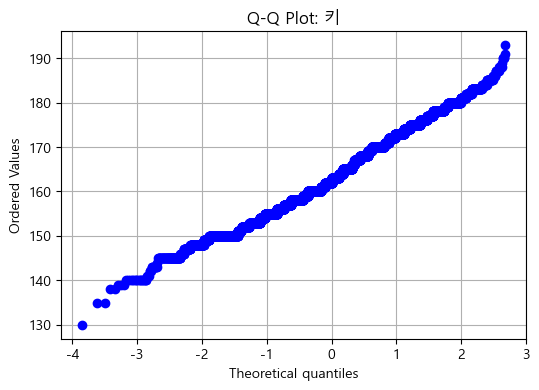

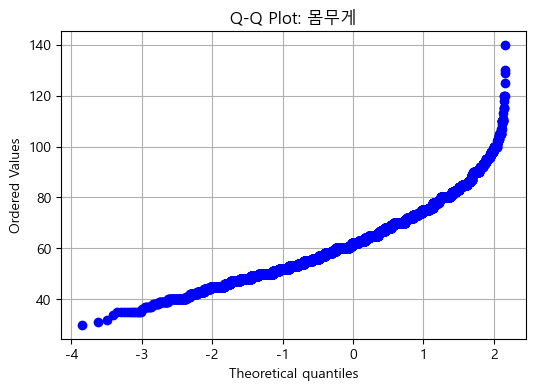

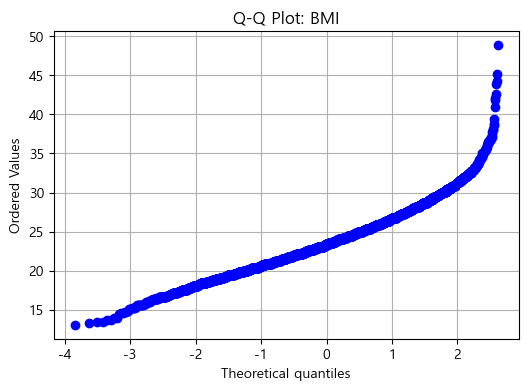

In [27]:
# 키, 몸무게, BMI 컬럼 정규성 띄는지 77777, 99999 결측치 처리 후 확인 Q-Q plot
import scipy.stats as stats
height_weight = ['키', '몸무게', 'BMI']
height_weight_invalid = [77777, 99999]
        
for col in height_weight:
    df_old[col] = df_old[col].replace(invalid_values, np.nan)
    
    plt.figure(figsize=(6, 4))
    stats.probplot(df_old[col], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot: {col}')
    plt.grid(True)
    plt.show()


In [28]:
# # Histogram으로 데이터 분포 확인
# import matplotlib.pyplot as plt
# import seaborn as sns

# for i, col in enumerate(df_old.columns):
#     plt.figure(figsize=(8, 4))
#     sns.histplot(df_old[col].dropna(), kde=True, bins=30)
#     plt.title(f'Distribution of {col}')
#     plt.xlabel(col)
#     plt.ylabel('Frequency')
#     plt.tight_layout()
#     plt.show()

In [29]:
# 키, 몸무게, BMI 결측치를 중앙값으로 대체하기
for col in height_weight:
    hw_median = df_old[col].median()
    df_old[col] = df_old[col].fillna(hw_median)

In [30]:
# 평균 수면 시간에 88이 없어서 77과 99를 따로 처리하기
sleep_cols = ['주중 평균 수면시간', '주말 평균 수면시간']

for col in sleep_cols:
    # 77, 99를 일단 NaN으로 바꾸기
    df_old[col] = df_old[col].replace([77, 99], np.nan)

# 결과 확인
print(df_old['주중 평균 수면시간'].value_counts())
print(df_old['주말 평균 수면시간'].value_counts())


주중 평균 수면시간
6.0     3420
7.0     3402
8.0     1805
5.0     1726
4.0      539
9.0      226
10.0     172
3.0      108
12.0      32
2.0       17
11.0      10
1.0        3
23.0       3
21.0       2
14.0       1
Name: count, dtype: int64
주말 평균 수면시간
7.0     3201
6.0     2793
8.0     2420
5.0     1383
9.0      513
10.0     475
4.0      456
12.0      94
3.0       90
11.0      20
2.0       15
1.0        3
15.0       2
14.0       1
Name: count, dtype: int64


In [31]:
# IQR로 수면 시간 이상치 대체

def replace_outliers_with_median(df, column, weight=1.5):
    # 결측치 제외한 값으로 사분위 계산
    q25 = np.percentile(df[column].dropna(), 25)
    q75 = np.percentile(df[column].dropna(), 75)
    iqr = q75 - q25

    # 이상치 범위 계산
    lower_bound = q25 - (iqr * weight)
    upper_bound = q75 + (iqr * weight)

    # 중앙값 계산 (결측치 제외)
    median = df[column].median()

    # 이상치, 결측치 중앙값으로 대체
    df.loc[(df[column] < lower_bound) | (df[column] > upper_bound), column] = median
    # 위의 코드에서 발생한 결측치도 중앙값으로 대체
    df[column] = df[column].fillna(median)


cols = ['주중 평균 수면시간', '주말 평균 수면시간']
for col in cols:
    replace_outliers_with_median(df_old, col)

In [32]:
# 결측치 확인
df_old.isnull().sum()

만나이                            0
성별                             0
치매 환자 가족 여부                    0
건강수준                           0
흡연 경험                          0
일반담배 흡연 경험                     0
일반담배 현재 흡연 여부                  0
일반담배 하루 평균 흡연량                 0
일반담배 간헐적 흡연자의 흡연일수             0
일반담배 간헐적 흡연자의 하루 평균 흡연량        0
일반담배 과거흡연자의 하루 평균 흡연량          0
일반담배 과거흡연자의 금연기간               0
궐련형 전자담배 현재 흡연 여부              0
궐련형 전자담배 하루 평균 흡연량             0
궐련형 전자담배 간헐적 흡연자의 흡연일수         0
궐련형 전자담배 간헐적 흡연자의 하루 평균 흡연량    0
액상형 전자담배 흡연자의 흡연일수             0
타 종류 담배 사용 경험                  0
가정 간접흡연 여부                     0
음주 경험                          0
연간 음주 빈도                       0
아침식수 일수                        0
키                              0
몸무게                            0
BMI                            0
주중 평균 수면시간                     0
주말 평균 수면시간                     0
스트레스 수준                        0
우울감 경험                         0
직무 흥미 저하                       0
우울감       

## 흡연 파생변수 생성
#### 전체담배 하루 평균 흡연량 = 모든 종류의 담배의 하루 평균 흡연량의 평균

In [33]:
# 전체 담배 하루 평균 흡연량
avg_smoking_col = [
    '일반담배 간헐적 흡연자의 하루 평균 흡연량',
    '일반담배 하루 평균 흡연량',
    '일반담배 과거흡연자의 하루 평균 흡연량',
    '궐련형 전자담배 하루 평균 흡연량',
    '궐련형 전자담배 간헐적 흡연자의 하루 평균 흡연량'
    ]
df_old['전체담배 하루 평균 흡연량'] = df_old[avg_smoking_col].sum(axis=1) / len(avg_smoking_col)
df_old.drop(columns=avg_smoking_col, inplace=True)

# 전체 담배 총 월간 흡연일 수 (단순 합산)
sum_smoking_days = [
    '일반담배 간헐적 흡연자의 흡연일수',
    '궐련형 전자담배 간헐적 흡연자의 흡연일수',
    '액상형 전자담배 흡연자의 흡연일수'
    ]
df_old['전체담배 흡연일수 합계'] = df_old[sum_smoking_days].sum(axis=1)
df_old.drop(columns=sum_smoking_days, inplace=True)

df_old.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11466 entries, 0 to 14515
Data columns (total 59 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   만나이                11466 non-null  int64  
 1   성별                 11466 non-null  int64  
 2   치매 환자 가족 여부        11466 non-null  float64
 3   건강수준               11466 non-null  int64  
 4   흡연 경험              11466 non-null  int64  
 5   일반담배 흡연 경험         11466 non-null  int64  
 6   일반담배 현재 흡연 여부      11466 non-null  int64  
 7   일반담배 과거흡연자의 금연기간   11466 non-null  int64  
 8   궐련형 전자담배 현재 흡연 여부  11466 non-null  int64  
 9   타 종류 담배 사용 경험      11466 non-null  int64  
 10  가정 간접흡연 여부         11466 non-null  int64  
 11  음주 경험              11466 non-null  int64  
 12  연간 음주 빈도           11466 non-null  int64  
 13  아침식수 일수            11466 non-null  int64  
 14  키                  11466 non-null  float64
 15  몸무게                11466 non-null  float64
 16  BMI                11466 no

# 우울증상 5가지 파생변수 생성
#### 직무 흥미 저하, 우울감, 수면장애, 무기력, 식이장애 총 5가지 변수를 하나의 파생변수로 생성

In [34]:
depression_col = [
    '직무 흥미 저하',
    '우울감',
    '수면장애',
    '무기력',
    '식이장애'
]

for col in depression_col:
    print(f"\n[{col}]")
    print(df_old[col].value_counts(dropna=False).sort_index())


[직무 흥미 저하]
직무 흥미 저하
1.0    8377
2.0    2355
3.0     325
4.0     409
Name: count, dtype: int64

[우울감]
우울감
1.0    8806
2.0    2103
3.0     276
4.0     281
Name: count, dtype: int64

[수면장애]
수면장애
1.0    6734
2.0    2744
3.0     697
4.0    1291
Name: count, dtype: int64

[무기력]
무기력
1.0    5522
2.0    4508
3.0     658
4.0     778
Name: count, dtype: int64

[식이장애]
식이장애
1.0    9060
2.0    1873
3.0     246
4.0     287
Name: count, dtype: int64


In [35]:
# 우울증상 지표 5가지를 '우울증상'이라는 하나의 파생변수로 생성
df_old['우울증상'] = df_old[depression_col].sum(axis=1)
df_old = df_old.drop(columns = depression_col)

In [36]:
df_old.describe()

,만나이,성별,치매 환자 가족 여부,건강수준,흡연 경험,일반담배 흡연 경험,일반담배 현재 흡연 여부,일반담배 과거흡연자의 금연기간,궐련형 전자담배 현재 흡연 여부,타 종류 담배 사용 경험,가정 간접흡연 여부,음주 경험,연간 음주 빈도,아침식수 일수,키,몸무게,BMI,주중 평균 수면시간,주말 평균 수면시간,스트레스 수준,우울감 경험,자기비하,집중력저하,활동둔화,자살충동,자살충동 여부,불면증,수면유지장애,야뇨증,수면호흡장애,수면 중 기침 및 코골이,수면 중 한기,수면 중 열감,수면 중 통증,수면 질,수면 약 복용,생활 중 졸음 정도,인지장애 경험 여부,치매선별검사 여부,고혈압 진단,혈압약 복용일수,당뇨병 진단,의료미충족,행복지수,운동 능력,자기 관리,일상 활동,통증 불편,불안 우울,보건기관 이용,경제 활동,연령대,전체담배 하루 평균 흡연량,전체담배 흡연일수 합계,우울증상
count,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.00000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000
mean,62.163701,1.568376,1.884528,2.938078,1.606925,0.774900,3.324089,5.663004,3.903803,2.989970,1.971830,1.160038,2.65873,1.611460,163.159585,62.863396,23.596607,6.461015,6.796267,3.098465,1.923164,1.101343,1.106489,1.044479,1.079627,1.918978,1.903628,2.286935,2.704169,1.087650,1.274464,1.111896,1.199634,1.328362,2.243590,1.218472,1.576574,1.745072,3.001483,1.644689,10.554596,1.833857,1.994069,6.836822,1.185854,1.070295,1.127856,1.365777,1.160300,1.824961,1.451596,2.779086,1.254631,0.618263,7.365690
std,12.451990,0.495324,0.319604,0.878787,0.488455,0.969307,1.027901,0.983858,0.472616,0.118077,0.165466,0.366658,1.66070,1.112591,8.553300,11.506988,3.180216,0.929765,1.399647,0.748532,0.266342,0.390940,0.399408,0.267650,0.351224,0.272881,1.202429,1.227963,1.162150,0.415667,0.721320,0.454606,0.599028,0.799843,0.675963,0.734053,0.952297,0.435840,2.441947,0.478628,14.634904,0.372226,0.316379,1.873442,0.408047,0.282556,0.361535,0.541672,0.401629,0.380017,0.497673,1.233895,1.990558,4.045232,2.801901
min,40.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,130.000000,30.000000,13.100000,5.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,5.000000
25%,52.000000,1.000000,2.000000,2.000000,1.000000,0.000000,3.000000,6.000000,4.000000,3.000000,2.000000,1.000000,1.00000,1.000000,157.000000,55.000000,21.500000,6.000000,6.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,0.000000,2.000000,2.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,0.000000,0.000000,5.000000
50%,63.000000,2.000000,2.000000,3.000000,2.000000,0.000000,4.000000,6.000000,4.000000,3.000000,2.000000,1.000000,2.00000,1.000000,162.000000,61.000000,23.300000,6.000000,7.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,2.000000,2.000000,0.000000,2.000000,2.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,0.000000,0.000000,7.000000
75%,71.000000,2.000000,2.000000,3.000000,2.000000,2.000000,4.000000,6.000000,4.000000,3.000000,2.000000,1.000000,4.00000,2.000000,170.000000,70.000000,25.400000,7.000000,8.000000,4.000000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,3.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.00000

# DNN 모델

In [39]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import (
    Layer, InputSpec, Dense, Dropout, Activation, Flatten, Input, LeakyReLU)
from tensorflow.keras.optimizers import RMSprop, SGD, Adam
from tensorflow.keras import (
    initializers, regularizers, constraints, backend as K)
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, History, EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.metrics import AUC
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, accuracy_score, 
                             precision_score, recall_score, f1_score, average_precision_score, fbeta_score)
from sklearn.model_selection import train_test_split, StratifiedKFold 
from imblearn.over_sampling import SMOTE

## Oputna 

In [48]:
# 난수 값 고정
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

X = df_old.drop(columns=['인지장애 경험 여부'])
y = df_old['인지장애 경험 여부'].replace(2, 0)

def objective(trial):

    n_units1  = trial.suggest_int('n_units1', 32, 256, step=32)
    n_units2  = trial.suggest_int('n_units2', 16, n_units1, step=16)
    dropout1 = trial.suggest_float('dropout1', 0.1, 0.5, step=0.1)  
    dropout2 = trial.suggest_float('dropout2', 0.1, 0.5, step=0.1)   
    lr = trial.suggest_loguniform('lr', 1e-4, 1e-2)
    batch_sz  = trial.suggest_categorical('batch_size', [32, 64, 128])
    activation = trial.suggest_categorical(
        'activation', ['relu', 'leaky_relu', 'elu', 'gelu'])
    optimizer = trial.suggest_categorical(
        'optimizer', ['adam', 'adamw', 'rmsprop', 'sgd'])
    skf = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)
    f1_scores = []

    for tr_idx, val_idx in skf.split(X, y):

        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        # 스케일링
        scaler = StandardScaler()
        X_tr  = scaler.fit_transform(X_tr)
        X_val = scaler.transform(X_val)

        # SMOTE
        X_tr, y_tr = SMOTE(random_state=42).fit_resample(X_tr, y_tr)


        K.clear_session()
        model = Sequential()

        # 첫 번째 은닉층
        model.add(Dense(n_units1, input_shape=(X_tr.shape[1],)),)
        if activation == 'leaky_relu':
            model.add(LeakyReLU(alpha=0.01))
        else:
            model.add(Activation(activation))
        model.add(Dropout(dropout1))

        # 두 번째 은닉층
        model.add(Dense(n_units2))
        if activation == 'leaky_relu':
            model.add(LeakyReLU(alpha=0.01))
        else:
            model.add(Activation(activation))
        model.add(Dropout(dropout2))

        # 출력층
        model.add(Dense(1, activation='sigmoid'))

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss='binary_crossentropy'
        )

        # 얼리스탑
        es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=200, batch_size=batch_sz,
            callbacks=[es], verbose=0
        )


        y_val_prob = model.predict(X_val, verbose=0).ravel()
        y_val_pred = (y_val_prob > 0.5).astype(int)

        f1_scores.append(f1_score(y_val, y_val_pred))

        trial.report(np.mean(f1_scores), len(f1_scores))
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(f1_scores)


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200, timeout=3600)

print(f'Best F1-Score : {study.best_value}')
print(f'Best Params : {study.best_params}')


best = study.best_params

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_res, y_res = SMOTE(random_state=42).fit_resample(X_scaled, y)

K.clear_session()
final_model = Sequential()

# 첫 번째 은닉층
final_model.add(Dense(best['n_units1'], input_shape=(X_res.shape[1],)))
if best['activation'] == 'leaky_relu':
    final_model.add(LeakyReLU(alpha=0.01))
else:
    final_model.add(Activation(best['activation']))
final_model.add(Dropout(best['dropout1']))

# 두 번째 은닉층
final_model.add(Dense(best['n_units2']))
if best['activation'] == 'leaky_relu':
    final_model.add(LeakyReLU(alpha=0.01))
else:
    final_model.add(Activation(best['activation']))
final_model.add(Dropout(best['dropout2']))

# 출력층
final_model.add(Dense(1, activation='sigmoid'))

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(best['lr']),
    loss='binary_crossentropy',
    metrics=['acc']
)

final_model.fit(
    X_res, y_res,
    validation_split=0.2,
    epochs=200, batch_size=best['batch_size'],
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=0
)

y_prob_f = final_model.predict(X_res, verbose=0).ravel()
y_pred_f = (y_prob_f > 0.5).astype(int)

print(f'F1 Score : {f1_score(y_res, y_pred_f):.4f}')
print(f'F2 Score : {fbeta_score(y_res, y_pred_f, beta=2):.4f}')


[I 2025-07-03 18:27:34,562] A new study created in memory with name: no-name-8b2fac06-ad8c-487e-b66c-6ee09cd9c19b
c:\DB\ml-project\venv\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\DB\ml-project\venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
c:\DB\ml-project\venv\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\DB\ml-project\venv\Lib\site-packages\keras

Best F1-Score : 0.5179893435655948
Best Params : {'n_units1': 128, 'n_units2': 96, 'dropout1': 0.4, 'dropout2': 0.5, 'lr': 0.00014060284355021726, 'batch_size': 128, 'activation': 'gelu', 'optimizer': 'rmsprop'}


c:\DB\ml-project\venv\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


F1 Score : 0.5717
F2 Score : 0.5043


## Best Params

k3
'n_units1': 128, 'n_units2': 32, 'dropout1': 0.4, 'dropout2': 0.4, 
'lr': 0.00013616509578041682, 'batch_size': 128, 'activation': 'elu', 'optimizer': 'adam'

k4 
{'n_units1': 192, 'n_units2': 160, 'dropout1': 0.5, 'dropout2': 0.2, 
'lr': 0.0002249776536284683, 'batch_size': 128, 'activation': 'leaky_relu', 'optimizer': 'adamw'}

k5
 {'n_units1': 256, 'n_units2': 192, 'dropout1': 0.5, 'dropout2': 0.30000000000000004, 'lr': 0.00014007916517904396, 'batch_size': 32, 'activation': 'relu', 'optimizer': 'adamw'}

k6
{'n_units1': 192, 'n_units2': 112, 'dropout1': 0.5, 'dropout2': 0.30000000000000004, 'lr': 0.00018134777792072827, 'batch_size': 32, 'activation': 'elu', 'optimizer': 'sgd'}

k7
n_units1': 128, 'n_units2': 96, 'dropout1': 0.4, 'dropout2': 0.5, 'lr': 0.00014060284355021726, 'batch_size': 128, 'activation': 'gelu', 'optimizer': 'rmsprop

## DNN 모델 - 최종 

In [57]:
# 난수 값 고정
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

X = df_old.drop(columns= ['인지장애 경험 여부'])
y = df_old['인지장애 경험 여부'].replace(2, 0)

skf = StratifiedKFold(n_splits=7, random_state=42, shuffle=True)

fold_results = []
metrics_list = []


for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    # 데이터 train, test 분할
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Standard 스케일링 적용
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # SMOTE 오버샘플링
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train) 

    # DNN 모델
    model = Sequential([
        Dense(128, activation='gelu', 
        input_shape=(X_train_resampled.shape[1],)),
        Dropout(0.4),
        Dense(96, activation= 'gelu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
])  
    model.compile(
        optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.00014060284355021726),
        loss='binary_crossentropy', metrics=['acc', AUC(name='auc')]
        )
    
    # 얼리스탑
    earlystop = EarlyStopping(
        patience=5, restore_best_weights=True
    )
    # 모델 학습
    history = model.fit(
        X_train_resampled, y_train_resampled, validation_data=(X_test_scaled, y_test),
        epochs=200, batch_size=128, verbose=0,
        callbacks=[earlystop]) 
    # 모델 예측
    y_proba = model.predict(X_test_scaled).ravel()
    y_pred = (y_proba > 0.5).astype(int)
    
    # 지표 계산
    pr_auc = average_precision_score(y_test, y_proba)
    metrics_list.append({
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred),
        'recall' : recall_score(y_test, y_pred),
        'f1' : f1_score(y_test, y_pred),
        'f2' : fbeta_score(y_test, y_pred, beta=2),
        'auc' : roc_auc_score(y_test, y_proba),
        'pr_auc' : pr_auc
    })    
    
    # k-Fold별 평가 지표
    print(f"[Fold {fold}] 결과")
    print(classification_report(y_test, y_pred, digits=4)) # 전체 리포트
    print(f"ROC AUC : {metrics_list[-1]['auc']:.4f}") # ROC AUC 
    print(f"PR AUC : {metrics_list[-1]['pr_auc']:.4f}") # PR AUC 

cv_df = pd.DataFrame(metrics_list)
cols = ['accuracy', 'precision', 'recall', 'f1', 'f2', 'auc', 'pr_auc']

print('=== K-Fold 평균 성능 ===')
print(cv_df[cols].mean(numeric_only=True).round(4))

c:\DB\ml-project\venv\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[Fold 1] 결과
              precision    recall  f1-score   support

         0.0     0.8603    0.6912    0.7666      1221
         1.0     0.4262    0.6715    0.5214       417

    accuracy                         0.6862      1638
   macro avg     0.6433    0.6813    0.6440      1638
weighted avg     0.7498    0.6862    0.7042      1638

ROC AUC : 0.7337
PR AUC : 0.5389


c:\DB\ml-project\venv\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
[Fold 2] 결과
              precision    recall  f1-score   support

         0.0     0.8655    0.7060    0.7776      1221
         1.0     0.4408    0.6787    0.5345       417

    accuracy                         0.6990      1638
   macro avg     0.6531    0.6923    0.6560      1638
weighted avg     0.7574    0.6990    0.7157      1638

ROC AUC : 0.7575
PR AUC : 0.5356


c:\DB\ml-project\venv\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
[Fold 5] 결과
              precision    recall  f1-score   support

         0.0     0.8596    0.7475    0.7996      1220
         1.0     0.4662    0.6435    0.5407       418

    accuracy                         0.7210      1638
   macro avg     0.6629    0.6955    0.6702      1638
weighted avg     0.7592    0.7210    0.7336      1638

ROC AUC : 0.7495
PR AUC : 0.5419


c:\DB\ml-project\venv\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
[Fold 6] 결과
              precision    recall  f1-score   support

         0.0     0.8408    0.6926    0.7596      1220
         1.0     0.4076    0.6172    0.4910       418

    accuracy                         0.6734      1638
   macro avg     0.6242    0.6549    0.6253      1638
weighted avg     0.7302    0.6734    0.6910      1638

ROC AUC : 0.7277
PR AUC : 0.5118


c:\DB\ml-project\venv\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[Fold 7] 결과
              precision    recall  f1-score   support

         0.0     0.8456    0.7270    0.7818      1220
         1.0     0.4346    0.6124    0.5084       418

    accuracy                         0.6978      1638
   macro avg     0.6401    0.6697    0.6451      1638
weighted avg     0.7407    0.6978    0.7121      1638

ROC AUC : 0.7325
PR AUC : 0.5344
=== K-Fold 평균 성능 ===
accuracy     0.6901
precision    0.4285
recall       0.6398
f1           0.5130
f2           0.5821
auc          0.7379
pr_auc       0.5291
dtype: float64


### 혼동행렬

In [ ]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

cm_total = np.zeros((2, 2), dtype=int)

cm_norm_list = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    ...
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    cm_total += cm                                 

    cm_norm = cm / cm.sum(axis=1, keepdims=True)   
    cm_norm_list.append(cm_norm)
    ...

plt.figure(figsize=(6,4))
sns.heatmap(cm_total, annot=True, fmt='d', cmap='Blues',
            xticklabels=['정상', '경도인지장애'],
            yticklabels=['정상', '경도인지장애'])
plt.title('Confusion Matrix 4-Fold Total')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()